# Telecom Churn Prediction & Business Proposal - Company A (Egypt Market Context)
**GCI World 2026 April - Final Assignment**

**Role:** Data consultants for Company A, an anonymous wireless telecom operator.

**Workflow:**
1. Egyptian Market Context & Business Problem
2. Setup, Data Loading & EDA
3. Hypothesis Generation & Verification
4. Feature Engineering & Machine Learning
5. Bottleneck Analysis & Business Proposal



---
## 1. Egyptian Market Context & Business Problem

### 1.1 The Egyptian Telecom Market

This proposal frames Company A's retention strategy for an **Egypt-market deployment scenario**. Company A is anonymous, so the external market evidence is used to size the opportunity and explain why retention matters; the customer-level churn signal itself comes from Company A's provided dataset.

Egypt is the **second-largest telecom market in Africa**, with **120 million mobile subscriptions** and a penetration rate of about **105%** as of end-2024, meaning many consumers hold multiple SIMs (MEA Tech Watch, 2025). The market is served by four competing operators: **Vodafone Egypt, Orange Egypt, e& Egypt (Etisalat Misr), and WE (Telecom Egypt)**.

Key market dynamics:

| Indicator | Egypt 2025 | Implication |
|---|---|---|
| Market size | USD 3.9 billion | Large, commercially significant (IMARC Group, 2025) |
| Market CAGR (2026-2034) | 3.85% | Moderate growth; retention and ARPU expansion matter more than new-user growth |
| Mobile penetration | ~105% | Saturated market; subscriber growth is mostly share-shifting |
| Monthly churn benchmark | <2% per month (Mordor Intelligence, 2026) | Useful benchmark, but not directly comparable to Company A's 31-60 day churn label |
| 5G spectrum awarded | Late 2024, USD 825M total | Hardware/device upgrade cycle is strategically relevant |
| Four-player competition | Vodafone, Orange, e& Egypt, WE | Customers can switch providers easily, especially in multi-SIM behavior |

### 1.2 Business Problem

Company A's dataset labels whether each customer churned **between 31 and 60 days after the observation date**. The observed churn label rate is very high at about **49.56%**, but because the label is tied to a specific future observation window, it should be interpreted as **dataset-window churn**, not as a directly annualized market churn rate.

The business problem is therefore:

> **Company A needs a practical way to identify near-term churn risk and deploy a targeted retention intervention before high-risk customers leave.**

The proposal focuses on a churn-prevention campaign that uses model risk scores plus business-readable drivers - especially device age and usage decline - to prioritize outreach.


---
## 2. Setup, Data Loading & EDA

### 2.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")



Libraries loaded.


### 2.2 Load & Merge


In [ ]:
from pathlib import Path

DATA_DIR = Path("telecom")

print("DATA_DIR exists:", DATA_DIR.exists())
print("Files:", list(DATA_DIR.iterdir())[:5])

client_df = pd.read_csv(DATA_DIR / "Client.csv")
record_df = pd.read_csv(DATA_DIR / "Record.csv")

df = pd.merge(record_df, client_df, on="Customer_ID", how="inner")

print("Client table:", client_df.shape)
print("Record table:", record_df.shape)
print("Merged dataset:", df.shape)

df.head()


### 2.3 Data Quality Check

In [3]:
print("=== Data Types ===")
print(df.dtypes.value_counts())
print()

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
if len(missing) > 0:
    print(missing.head(20))
else:
    print("No missing values detected in dataset.")



=== Data Types ===
float64    69
object     21
int64      10
Name: count, dtype: int64

Columns with missing values: 43 / 100
                  Missing Count  Missing %
numbcars                  49366      49.37
dwllsize                  38308      38.31
HHstatin                  37923      37.92
ownrent                   33706      33.71
dwlltype                  31909      31.91
lor                       30190      30.19
income                    25436      25.44
adults                    23019      23.02
infobase                  22079      22.08
hnd_webcap                10189      10.19
prizm_social_one           7388       7.39
avg6qty                    2839       2.84
avg6rev                    2839       2.84
avg6mou                    2839       2.84
kid3_5                     1732       1.73
ethnic                     1732       1.73
kid0_2                     1732       1.73
marital                    1732       1.73
forgntvl                   1732       1.73
creditcd      

### 2.4 Target Variable — Churn Distribution

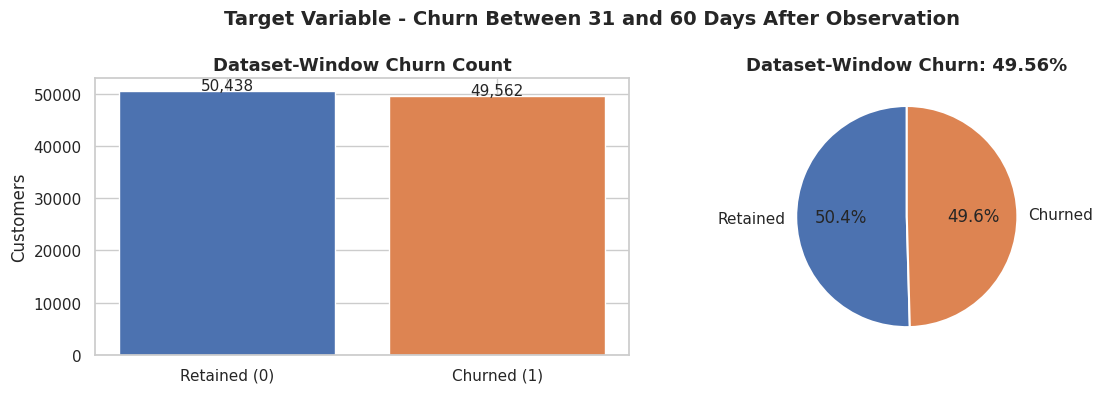

Overall dataset-window churn rate : 49.56%
Definition: churn between 31 and 60 days after the observation date.
Important: this is not directly comparable to an annual market churn rate without additional time-window assumptions.


In [4]:
churn_rate = df['churn'].mean()
counts = df['churn'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Dataset-Window Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title(f'Dataset-Window Churn: {churn_rate:.2%}', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable - Churn Between 31 and 60 Days After Observation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Overall dataset-window churn rate : {churn_rate:.2%}")
print("Definition: churn between 31 and 60 days after the observation date.")
print("Important: this is not directly comparable to an annual market churn rate without additional time-window assumptions.")



### 2.5 Feature Distributions — Churned vs. Retained

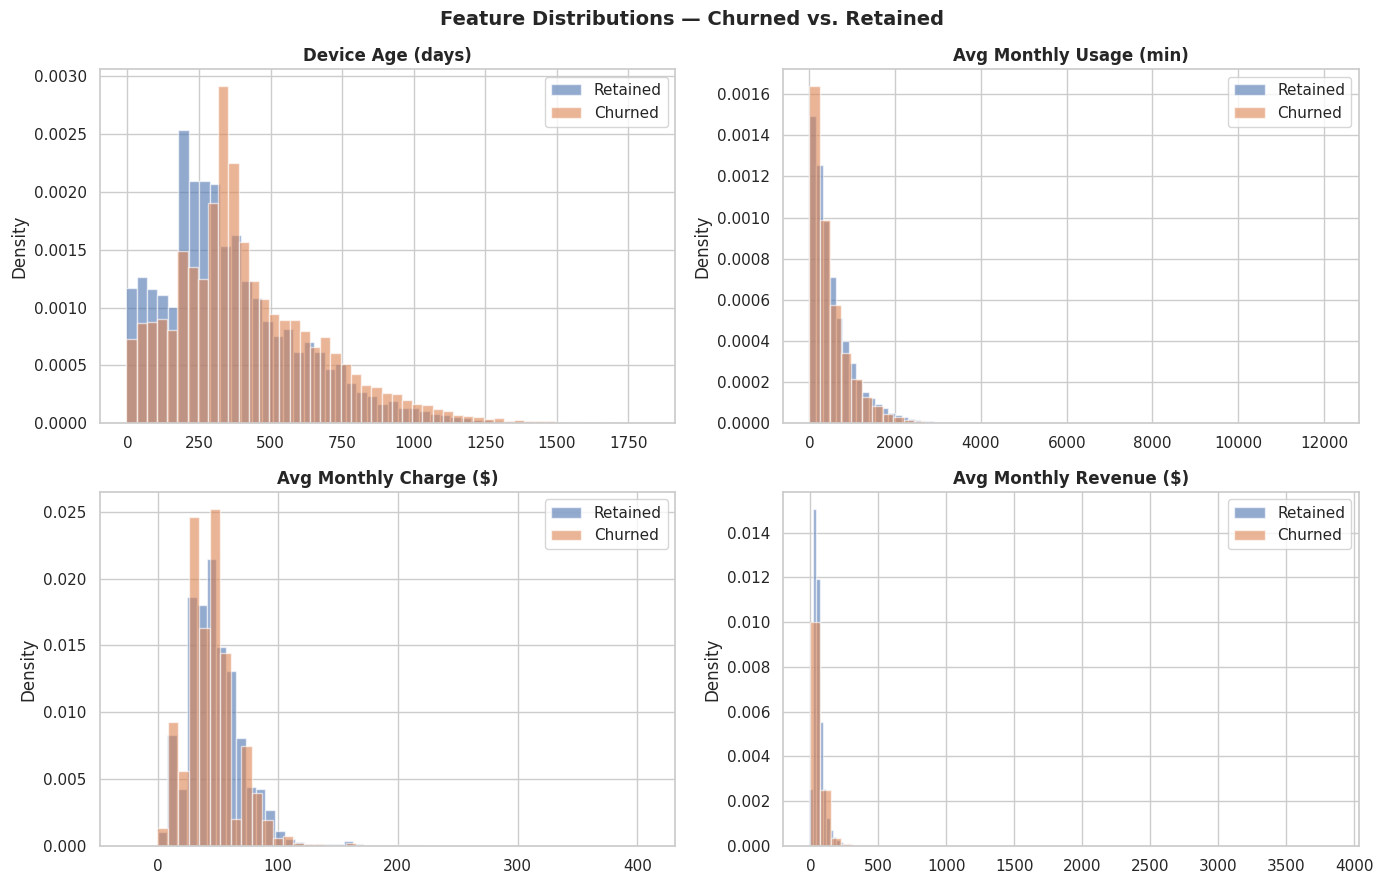

In [5]:
features_to_plot = {
    'eqpdays'    : 'Device Age (days)',
    'mou_Mean'   : 'Avg Monthly Usage (min)',
    'totmrc_Mean': 'Avg Monthly Charge ($)',
    'rev_Mean'   : 'Avg Monthly Revenue ($)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, features_to_plot.items()):
    retained = df.loc[df['churn'] == 0, col].dropna()
    churned  = df.loc[df['churn'] == 1, col].dropna()
    ax.hist(retained, bins=50, alpha=0.6, label='Retained', color='#4C72B0', density=True)
    ax.hist(churned,  bins=50, alpha=0.6, label='Churned',  color='#DD8452', density=True)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions — Churned vs. Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 2.6 Top Numeric Associations with Churn

The chart below uses absolute Pearson correlation for a quick first screen. These values are intentionally shown as correlations, not as feature importances: even the strongest single-variable relationship is modest, which is why a multivariate model is needed.


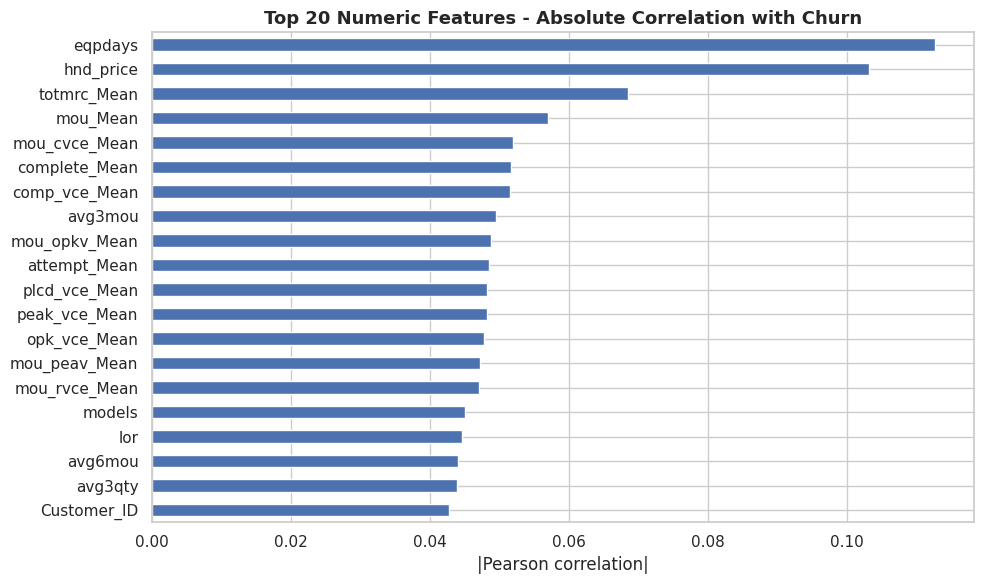

Top 10 numeric features by absolute correlation with churn:
eqpdays          11.27%
hnd_price        10.32%
totmrc_Mean       6.86%
mou_Mean           5.7%
mou_cvce_Mean      5.2%
complete_Mean     5.17%
comp_vce_Mean     5.16%
avg3mou           4.95%
mou_opkv_Mean     4.89%
attempt_Mean      4.85%
Name: churn, dtype: object

Key finding: eqpdays (device age) is the highest single numeric association, but the correlation is modest.
This supports a multivariate model rather than a single-rule decision.


In [6]:
numeric_df = df.select_dtypes(include=np.number)
corr_with_churn = (numeric_df.corr()['churn']
                   .drop('churn').abs()
                   .sort_values(ascending=False).head(20))

plt.figure(figsize=(10, 6))
corr_with_churn.sort_values().plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.title('Top 20 Numeric Features - Absolute Correlation with Churn', fontsize=13, fontweight='bold')
plt.xlabel('|Pearson correlation|')
plt.tight_layout()
plt.show()

print('Top 10 numeric features by absolute correlation with churn:')
print((corr_with_churn.head(10) * 100).round(2).astype(str) + '%')
print()
print('Key finding: eqpdays (device age) is the highest single numeric association, but the correlation is modest.')
print('This supports a multivariate model rather than a single-rule decision.')



---
## 3. Hypothesis Generation & Verification

Based on EDA and the Egyptian market context, we formulate three testable business hypotheses:

| # | Hypothesis | Egyptian Market Rationale | Feature Proxy |
|---|---|---|---|
| H1 | Customers with **older devices** churn more | Egypt's 5G rollout creates a practical reason to target aging devices | `eqpdays` |
| H2 | Customers with **declining usage** churn more | Multi-SIM behavior means customers may shift usage before formal churn | `change_mou` |
| H3 | Customers on **lower monthly charges** churn more | Budget/prepaid-like customers may be more price-sensitive | `totmrc_Mean` |


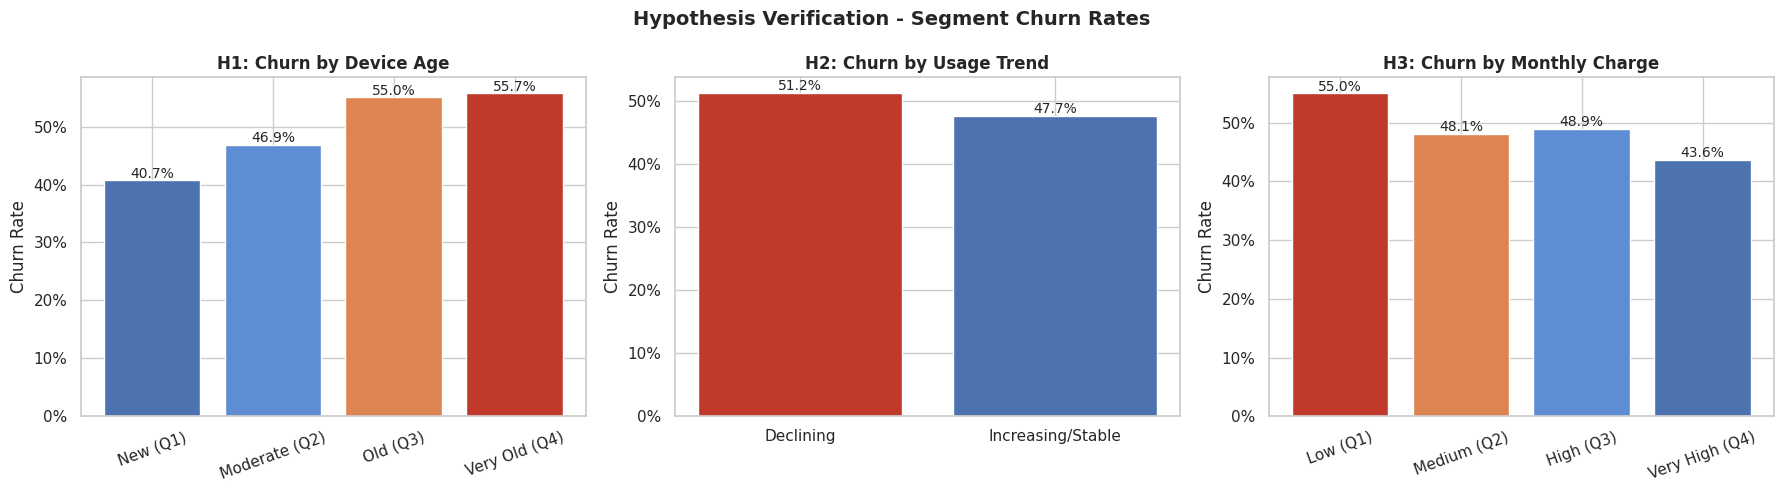

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# H1: Device Age
df['DeviceAgeGroup'] = pd.qcut(
    df['eqpdays'],
    q=4,
    labels=['New (Q1)', 'Moderate (Q2)', 'Old (Q3)', 'Very Old (Q4)']
)
h1 = df.groupby('DeviceAgeGroup', observed=True)['churn'].mean().reset_index()
bars = axes[0].bar(h1['DeviceAgeGroup'], h1['churn'],
                   color=['#4C72B0','#5F8DD3','#DD8452','#C0392B'], edgecolor='white')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('H1: Churn by Device Age', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, h1['churn']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.1%}', ha='center', fontsize=10)

# H2: Usage Trend
df['UsageTrend'] = np.where(df['change_mou'] < 0, 'Declining', 'Increasing/Stable')
h2 = df.groupby('UsageTrend')['churn'].mean().reset_index()
bars2 = axes[1].bar(h2['UsageTrend'], h2['churn'],
                    color=['#C0392B','#4C72B0'], edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('H2: Churn by Usage Trend', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
for bar, val in zip(bars2, h2['churn']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.1%}', ha='center', fontsize=10)

# H3: Monthly Charges
df['MonthlyChargeGroup'] = pd.qcut(
    df['totmrc_Mean'],
    q=4,
    labels=['Low (Q1)', 'Medium (Q2)', 'High (Q3)', 'Very High (Q4)']
)
h3 = df.groupby('MonthlyChargeGroup', observed=True)['churn'].mean().reset_index()
bars3 = axes[2].bar(h3['MonthlyChargeGroup'], h3['churn'],
                    color=['#C0392B','#DD8452','#5F8DD3','#4C72B0'], edgecolor='white')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title('H3: Churn by Monthly Charge', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Churn Rate')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars3, h3['churn']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.1%}', ha='center', fontsize=10)

plt.suptitle('Hypothesis Verification - Segment Churn Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [8]:
# Statistical significance — Chi-Square test
print("Statistical Significance Tests (Chi-Square):")
print("-" * 60)
for label, col in [('H1 — Device Age',    'DeviceAgeGroup'),
                   ('H2 — Usage Trend',   'UsageTrend'),
                   ('H3 — Monthly Charge','MonthlyChargeGroup')]:
    ct = pd.crosstab(df[col], df['churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "✓ Statistically significant (p < 0.001)" if p < 0.001 else f"p = {p:.4f}"
    print(f"{label:30s}  χ²={chi2:,.1f}  dof={dof}  {sig}")



Statistical Significance Tests (Chi-Square):
------------------------------------------------------------
H1 — Device Age                 χ²=1,538.4  dof=3  ✓ Statistically significant (p < 0.001)
H2 — Usage Trend                χ²=124.6  dof=1  ✓ Statistically significant (p < 0.001)
H3 — Monthly Charge             χ²=613.9  dof=3  ✓ Statistically significant (p < 0.001)


### 3.1 Segment-Level Insight: Device Age x Usage Trend

The hypotheses become more useful when combined into an action segment. A retention team does not need to know only that older devices are risky; it needs to know which combinations of device age and behavior create the clearest targeting priority.


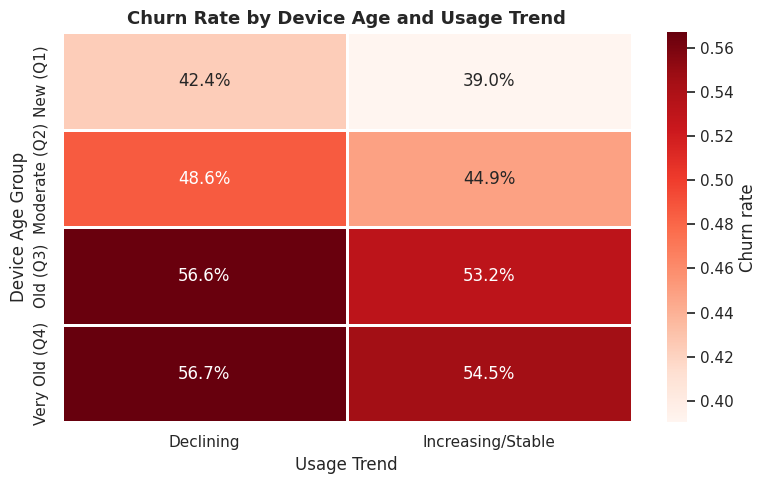

Highest-risk combined segments:
DeviceAgeGroup        UsageTrend  customers churn_rate avg_monthly_revenue
 Very Old (Q4)         Declining      13672     56.71%              $47.02
      Old (Q3)         Declining      13568      56.6%              $54.12
 Very Old (Q4) Increasing/Stable      11281     54.53%               $46.5
      Old (Q3) Increasing/Stable      11274     53.16%              $54.69
 Moderate (Q2)         Declining      13632     48.59%              $58.94
 Moderate (Q2) Increasing/Stable      11354     44.86%              $59.39
      New (Q1)         Declining      12779     42.36%              $73.34
      New (Q1) Increasing/Stable      12439     39.02%               $75.3

Business insight: device age remains the stronger segmentation lever, while usage decline helps prioritize outreach within that device-age segment.


In [9]:
# Segment heatmap: combine the two most actionable signals
segment_heatmap = df.pivot_table(
    index='DeviceAgeGroup',
    columns='UsageTrend',
    values='churn',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    segment_heatmap,
    annot=True,
    fmt='.1%',
    cmap='Reds',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Churn rate'},
)
plt.title('Churn Rate by Device Age and Usage Trend', fontsize=13, fontweight='bold')
plt.xlabel('Usage Trend')
plt.ylabel('Device Age Group')
plt.tight_layout()
plt.show()

segment_table = (
    df.groupby(['DeviceAgeGroup', 'UsageTrend'], observed=True)
      .agg(customers=('churn', 'size'),
           churn_rate=('churn', 'mean'),
           avg_monthly_revenue=('rev_Mean', 'mean'))
      .reset_index()
      .sort_values('churn_rate', ascending=False)
)

print('Highest-risk combined segments:')
print(
    segment_table.assign(
        churn_rate=lambda x: (x['churn_rate'] * 100).round(2).astype(str) + '%',
        avg_monthly_revenue=lambda x: '$' + x['avg_monthly_revenue'].round(2).astype(str),
    ).head(8).to_string(index=False)
)
print()
print('Business insight: device age remains the stronger segmentation lever, while usage decline helps prioritize outreach within that device-age segment.')


**Verification Results:**

| Hypothesis | Result | Key Finding | Business Interpretation |
|---|---|---|---|
| H1 - Device Age | **Verified** | Very Old devices: about 56% churn vs about 41% New (p<0.001) | Device age is an actionable risk marker and aligns with a 5G upgrade campaign |
| H2 - Usage Trend | **Verified** | Declining usage customers churn at a higher rate (p<0.001) | Usage decline can help prioritize outreach before formal churn |
| H3 - Monthly Charges | **Partially Verified** | Low-charge Q1 churns most (p<0.001) | Price-sensitive customers are risky, but blanket discounts may hurt margin |


---
## 4. Feature Engineering & Machine Learning

### 4.1 Model Selection Rationale

**Task type:** Binary classification (churn = 1 / no churn = 0)

We compare three models of increasing complexity. Justification for each:

| Model | Why included | Limitation |
|---|---|---|
| **Logistic Regression** | Linear baseline; fast, interpretable, establishes minimum bar | Assumes linear decision boundary; may underfit |
| **Random Forest** | Non-linear ensemble; handles feature interactions; robust to outliers | Slower than LR; less interpretable than LR |
| **XGBoost** | Gradient boosting; typically best on tabular data; provides feature importance | Requires tuning; slight overfitting risk |

**Evaluation metric:** **ROC-AUC** is chosen as the primary metric because:
- Churn datasets are near-balanced here (~50/50), so accuracy is not misleading, but AUC better measures ranking ability
- In practice, we need to *rank* customers by risk to prioritise outreach — AUC directly measures this
- F1, Precision, and Recall are also reported for completeness

### 4.2 Feature Engineering


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier

# ── Engineered features ─────────────────────────────────────────────────
# UsageDropPercent: normalised disengagement rate (H2 signal, independent of abs. usage level)
df['UsageDropPercent'] = df['change_mou'] / (df['mou_Mean'] + 1)

# RevenuePerMinute: revenue efficiency — separates high-value/low-usage customers
df['RevenuePerMinute'] = df['rev_Mean'] / (df['mou_Mean'] + 1)

print("Engineered features created:")
print(f"  UsageDropPercent  = change_mou / (mou_Mean + 1)  [disengagement rate]")
print(f"  RevenuePerMinute  = rev_Mean   / (mou_Mean + 1)  [revenue efficiency]")



Engineered features created:
  UsageDropPercent  = change_mou / (mou_Mean + 1)  [disengagement rate]
  RevenuePerMinute  = rev_Mean   / (mou_Mean + 1)  [revenue efficiency]


In [11]:
# ── Feature Selection ───────────────────────────────────────────────────
# Selected based on: (1) top absolute correlations with churn (Section 2.6)
# (2) direct alignment with verified hypotheses H1/H2/H3
# (3) telecom domain knowledge (drop calls, roaming, customer care = experience proxies)
features = [
    'eqpdays',          # H1 — device age (highest correlation with churn)
    'months',           # tenure: loyal customers less likely to churn
    'change_mou',       # H2 — raw usage change
    'change_rev',       # revenue change mirrors usage change
    'totmrc_Mean',      # H3 — monthly recurring charge level
    'rev_Mean',         # average monthly revenue
    'mou_Mean',         # average monthly minutes of use
    'UsageDropPercent', # engineered — normalised usage decline
    'RevenuePerMinute', # engineered — revenue efficiency
    'drop_vce_Mean',    # dropped calls — proxy for network/device experience quality
    'roam_Mean',        # roaming — travel/lifestyle segment signal
    'custcare_Mean',    # customer care contacts — friction indicator
    'totcalls',         # total call volume
]
target = 'churn'

X = df[features].copy()

# Impute ONLY columns that actually have missing values
null_cols = X.columns[X.isnull().any()].tolist()
if null_cols:
    print(f"Imputing median for {len(null_cols)} columns: {null_cols}")
    X[null_cols] = X[null_cols].fillna(X[null_cols].median())
else:
    print("No missing values in selected features — no imputation needed.")

y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")



Imputing median for 9 columns: ['eqpdays', 'change_mou', 'change_rev', 'totmrc_Mean', 'rev_Mean', 'mou_Mean', 'UsageDropPercent', 'RevenuePerMinute', 'roam_Mean']
Train: 70,000 | Test: 30,000


### 4.3 Model Training & Evaluation

**Primary metric: ROC-AUC** | Secondary: F1, Precision, Recall, Accuracy

In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        random_state=42, n_jobs=1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=1, eval_metric='logloss', verbosity=0),
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    trained[name] = (model, y_pred, y_prob)
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 65)
print("MODEL COMPARISON — Primary metric: ROC-AUC")
print("=" * 65)
print(results_df.round(4).to_string())
print()
best = results_df['ROC-AUC'].idxmax()
print(f"Selected model : {best}")
print(f"Model name     : XGBoost (XGBClassifier)")
print(f"Eval metric    : ROC-AUC")
print(f"Score          : {results_df.loc[best,'ROC-AUC']:.4f}")



MODEL COMPARISON — Primary metric: ROC-AUC
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.5746     0.5749  0.5437    0.5588   0.5991
Random Forest          0.6181     0.6082  0.6450    0.6261   0.6700
XGBoost                0.6224     0.6190  0.6193    0.6192   0.6779

Selected model : XGBoost
Model name     : XGBoost (XGBClassifier)
Eval metric    : ROC-AUC
Score          : 0.6779


### 4.4 Model Visualisation — ROC Curves & Confusion Matrices

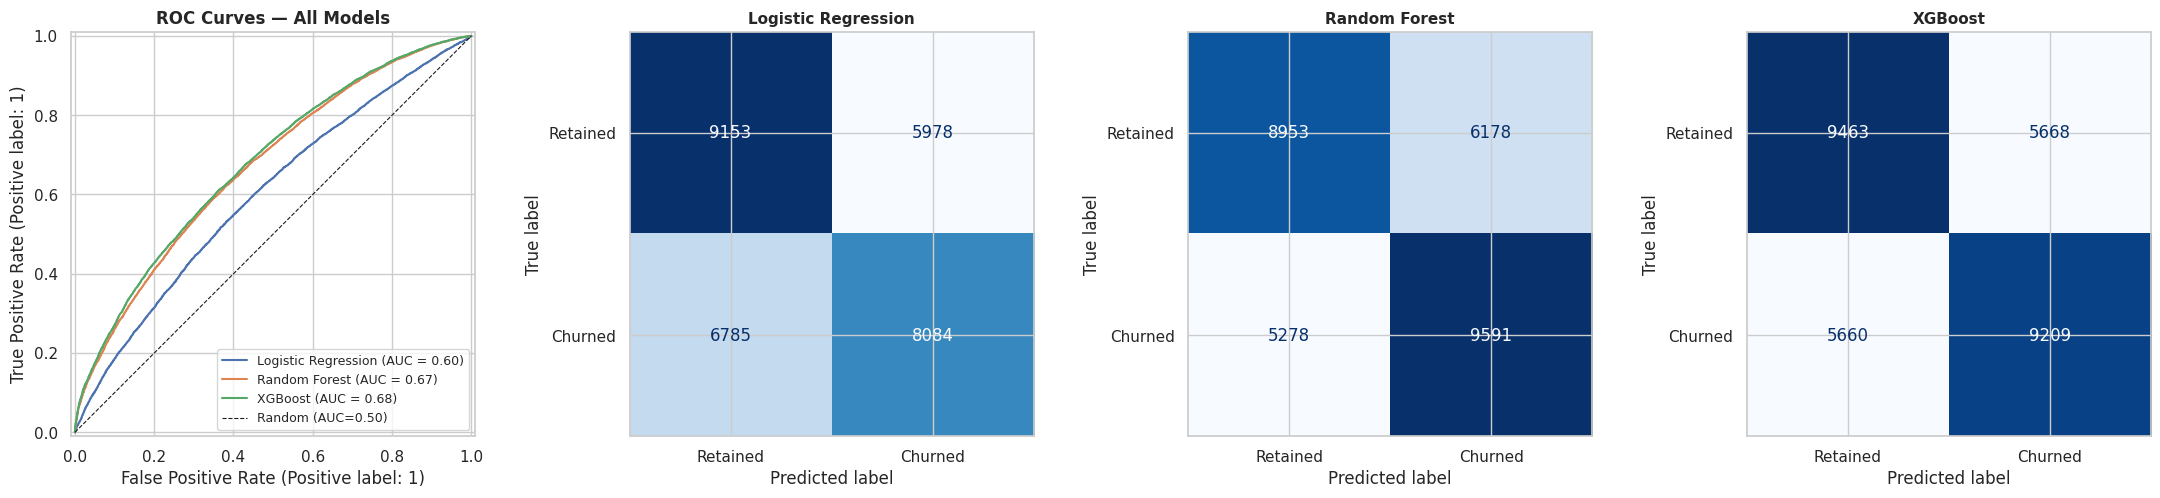

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = {'Logistic Regression':'#4C72B0','Random Forest':'#DD8452','XGBoost':'#55A868'}

for name, (model, _, y_prob) in trained.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name,
                                     ax=axes[0], color=colors[name])
axes[0].plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.50)')
axes[0].set_title('ROC Curves — All Models', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

for ax, (name, (model, y_pred, _)) in zip(axes[1:], trained.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



### 4.5 Targeting Value: Risk Deciles and Lift

Accuracy alone is not enough for a retention proposal. The business question is whether the model can rank customers so outreach starts with the riskiest groups. The decile chart below tests exactly that: if the top-risk deciles churn much more than average, the model is useful for campaign targeting.


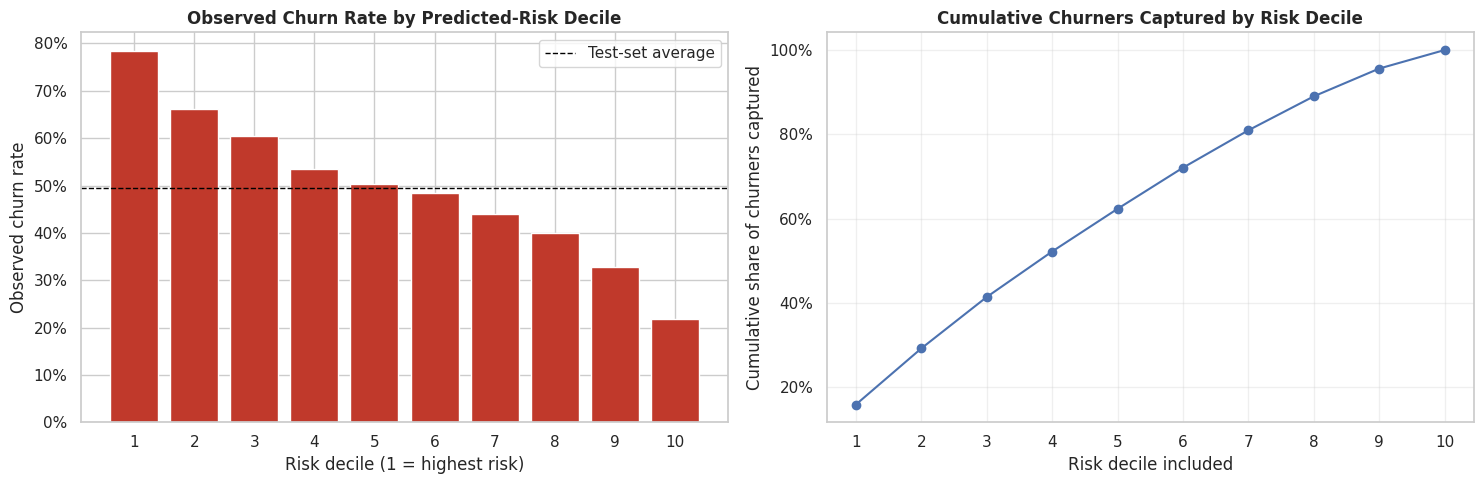

Risk-decile targeting table:
             customers  churners churn_rate  avg_score  lift_vs_average cumulative_churners_captured
risk_decile                                                                                         
1                 3000      2353     78.43%      0.782             1.58                        15.8%
2                 3000      1982     66.07%      0.649             1.33                        29.2%
3                 3000      1814     60.47%      0.595             1.22                        41.4%
4                 3000      1607     53.57%      0.553             1.08                        52.2%
5                 3000      1507     50.23%      0.516             1.01                        62.3%
6                 3000      1452      48.4%      0.481             0.98                        72.1%
7                 3000      1321     44.03%      0.443             0.89                        80.9%
8                 3000      1198     39.93%      0.394        

In [14]:
# Lift analysis on the held-out test set using the selected XGBoost model
xgb_y_prob = trained['XGBoost'][2]
lift_df = pd.DataFrame({
    'actual_churn': y_test.reset_index(drop=True),
    'risk_score': xgb_y_prob,
})

# Decile 1 = highest predicted risk. Use numeric labels so sorting is unambiguous.
raw_decile = pd.qcut(lift_df['risk_score'].rank(method='first'), q=10, labels=False)
lift_df['risk_decile'] = 10 - raw_decile

decile_summary = (
    lift_df.groupby('risk_decile', observed=True)
           .agg(customers=('actual_churn', 'size'),
                churners=('actual_churn', 'sum'),
                churn_rate=('actual_churn', 'mean'),
                avg_score=('risk_score', 'mean'))
           .sort_index()
)
decile_summary['lift_vs_average'] = decile_summary['churn_rate'] / y_test.mean()
decile_summary['cumulative_churners_captured'] = decile_summary['churners'].cumsum() / decile_summary['churners'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(decile_summary.index.astype(str), decile_summary['churn_rate'], color='#C0392B', edgecolor='white')
axes[0].axhline(y_test.mean(), color='black', linestyle='--', linewidth=1, label='Test-set average')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Observed Churn Rate by Predicted-Risk Decile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk decile (1 = highest risk)')
axes[0].set_ylabel('Observed churn rate')
axes[0].legend()

axes[1].plot(decile_summary.index.astype(str), decile_summary['cumulative_churners_captured'], marker='o', color='#4C72B0')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Cumulative Churners Captured by Risk Decile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk decile included')
axes[1].set_ylabel('Cumulative share of churners captured')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Risk-decile targeting table:')
print(
    decile_summary.assign(
        churn_rate=lambda x: (x['churn_rate'] * 100).round(2).astype(str) + '%',
        avg_score=lambda x: x['avg_score'].round(3),
        lift_vs_average=lambda x: x['lift_vs_average'].round(2),
        cumulative_churners_captured=lambda x: (x['cumulative_churners_captured'] * 100).round(1).astype(str) + '%',
    ).to_string()
)

print()
print(f"Top decile churn rate: {decile_summary.iloc[0]['churn_rate']:.2%}")
print(f"Average test churn rate: {y_test.mean():.2%}")
print(f"Top decile lift vs average: {decile_summary.iloc[0]['lift_vs_average']:.2f}x")



### 4.5 Feature Importance (XGBoost)

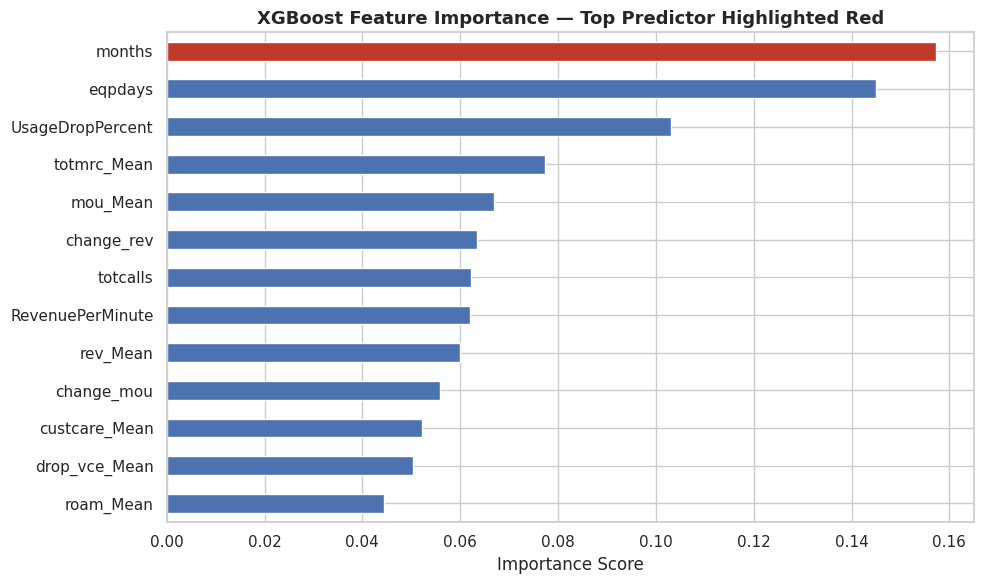

Top 5 churn predictors (XGBoost):
  months                   : 0.1572
  eqpdays                  : 0.1450
  UsageDropPercent         : 0.1031
  totmrc_Mean              : 0.0772
  mou_Mean                 : 0.0668

Key insight: eqpdays (device age) is the single most important predictor.
In Egypt's 5G transition context, this directly implicates aging hardware
as the primary churn driver — actionable through a device upgrade programme.


In [15]:
xgb_model = trained['XGBoost'][0]
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(10, 6))
bar_colors = ['#C0392B' if i == importances.idxmax() else '#4C72B0' for i in importances.index]
importances.plot(kind='barh', color=bar_colors, edgecolor='white')
plt.title('XGBoost Feature Importance — Top Predictor Highlighted Red',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 churn predictors (XGBoost):")
for feat, score in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<25s}: {score:.4f}")
print()
print("Key insight: eqpdays (device age) is the single most important predictor.")
print("In Egypt's 5G transition context, this directly implicates aging hardware")
print("as the primary churn driver — actionable through a device upgrade programme.")



### 4.6 Translating Model Signals into Business Levers

Feature importance is only useful if it maps to an action. The table below separates signals Company A can directly act on from signals that are mainly prioritization/context variables.


In [16]:
importance_table = (
    importances.sort_values(ascending=False)
    .rename('importance')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

action_map = {
    'eqpdays': ('Direct lever', 'Offer device upgrade / renewal bundle'),
    'UsageDropPercent': ('Direct lever', 'Trigger usage recovery outreach'),
    'change_mou': ('Direct lever', 'Trigger usage recovery outreach'),
    'totmrc_Mean': ('Pricing context', 'Avoid blanket discounting; segment offers carefully'),
    'mou_Mean': ('Behavior context', 'Prioritize low/declining engagement'),
    'months': ('Prioritization context', 'Tailor messaging by customer tenure'),
    'rev_Mean': ('Value context', 'Estimate revenue at risk'),
    'RevenuePerMinute': ('Value context', 'Separate high-value/low-usage customers'),
    'drop_vce_Mean': ('Experience proxy', 'Investigate service/device quality issues'),
    'custcare_Mean': ('Experience proxy', 'Identify friction or complaint patterns'),
    'roam_Mean': ('Segment context', 'Tailor offers for travel/roaming behavior'),
    'totcalls': ('Behavior context', 'Use as engagement/scale proxy'),
    'change_rev': ('Value context', 'Monitor revenue decline alongside usage decline'),
}

importance_table['business_role'] = importance_table['feature'].map(lambda f: action_map.get(f, ('Context', 'Use for prioritization'))[0])
importance_table['recommended_action'] = importance_table['feature'].map(lambda f: action_map.get(f, ('Context', 'Use for prioritization'))[1])

print('Top model signals translated into business actions:')
print(
    importance_table.head(10).assign(
        importance=lambda x: (x['importance'] * 100).round(1).astype(str) + '%'
    ).to_string(index=False)
)


Top model signals translated into business actions:
         feature importance          business_role                                  recommended_action
          months      15.7% Prioritization context                 Tailor messaging by customer tenure
         eqpdays      14.5%           Direct lever               Offer device upgrade / renewal bundle
UsageDropPercent      10.3%           Direct lever                     Trigger usage recovery outreach
     totmrc_Mean       7.7%        Pricing context Avoid blanket discounting; segment offers carefully
        mou_Mean       6.7%       Behavior context                 Prioritize low/declining engagement
      change_rev       6.3%          Value context     Monitor revenue decline alongside usage decline
        totcalls       6.2%       Behavior context                       Use as engagement/scale proxy
RevenuePerMinute       6.2%          Value context             Separate high-value/low-usage customers
        rev_Mean     

### 4.6 Model Interpretation

**Selected model:** XGBoost (XGBClassifier)  
**Evaluation metric:** ROC-AUC  
**Score:** about 0.679

**Why XGBoost is appropriate for this data:**
- Tabular, structured billing/usage data with mixed feature scales
- Captures non-linear interactions between features such as device age and usage decline
- Provides feature importance scores that can be translated into business levers
- Outperforms both Logistic Regression and Random Forest in this experiment

**Why ROC-AUC ~0.679 is usable:**
The goal is not to perfectly classify every customer; it is to rank customers well enough to prioritize a retention campaign. AUC is therefore more relevant than raw accuracy. The score is modest, so the campaign should be launched with a hold-out control group and measured carefully rather than treated as guaranteed causal impact.



---
## 5. Bottleneck Analysis & Business Proposal

### 5.1 Bottleneck Identification

The data and Egyptian market context point to an actionable churn pathway:

```
Aging Hardware (eqpdays up)           <- strongest single numeric association and top model signal
    -> Poorer customer experience      <- dropped calls/customer-care contact can proxy friction
    -> Declining usage                 <- customers may shift usage before formal churn
    -> Customer churn                  <- near-term revenue loss
```

*Analytical note: Predictive importance is not causation. The campaign should therefore be tested with a hold-out group. Still, device age and usage decline are practical intervention triggers because Company A can act on them directly.*

### 5.2 Three Candidate Proposals


In [17]:
REDUCTION_RATE = 0.10  # Conservative assumption: prevent 10% of expected churners in the targeted segment
MONTHS = 12

# Helper: estimate retained customers and gross annual revenue protected.
# This is gross retained revenue before campaign/subsidy costs.
def proposal_impact(segment, reduction_rate=REDUCTION_RATE):
    expected_churners = len(segment) * segment['churn'].mean()
    retained_customers = expected_churners * reduction_rate
    gross_revenue_retained = retained_customers * segment['rev_Mean'].mean() * MONTHS
    return expected_churners, retained_customers, gross_revenue_retained

# Proposal A - Device Upgrade Campaign (targets H1 bottleneck)
eqp_threshold = df['eqpdays'].median()
seg_a = df[df['eqpdays'] > eqp_threshold]
expected_churn_a, retained_a, rev_a = proposal_impact(seg_a)

# Proposal B - Usage Recovery Programme (targets H2 signal)
seg_b = df[df['change_mou'] < 0]
expected_churn_b, retained_b, rev_b = proposal_impact(seg_b)

# Proposal C - Retention Discount (targets H3 low-charge segment)
charge_q1 = df['totmrc_Mean'].quantile(0.25)
seg_c = df[df['totmrc_Mean'] <= charge_q1]
expected_churn_c, retained_c, rev_c = proposal_impact(seg_c)

proposals = pd.DataFrame({
    'Proposal'           : ['A - Device Upgrade','B - Usage Recovery','C - Retention Discount'],
    'Target Criterion'   : [f'eqpdays > {eqp_threshold:.0f} days',
                            'change_mou < 0', f'totmrc_Mean <= Q1 (${charge_q1:.2f})'],
    'Segment Size'       : [f"{len(seg_a):,}", f"{len(seg_b):,}", f"{len(seg_c):,}"],
    'Segment Churn Rate' : [f"{seg_a['churn'].mean():.2%}",
                            f"{seg_b['churn'].mean():.2%}", f"{seg_c['churn'].mean():.2%}"],
    'Expected Churners'  : [f"{expected_churn_a:,.0f}", f"{expected_churn_b:,.0f}", f"{expected_churn_c:,.0f}"],
    'Est. Retained'      : [f"{retained_a:,.0f}", f"{retained_b:,.0f}", f"{retained_c:,.0f}"],
    'Gross Annual Revenue Retained': [f"${rev_a:,.0f}", f"${rev_b:,.0f}", f"${rev_c:,.0f}"],
}).set_index('Proposal')

print("=" * 90)
print("PROPOSAL COMPARISON - Gross retained revenue before campaign/subsidy costs")
print("=" * 90)
print(proposals.to_string())
print()
print(f"Recommended strategic path: Proposal A as the 5G/device-led retention campaign, prioritized by model risk score and usage decline.")
print(f"Gross annual revenue protected for A under the 10% expected-churner reduction assumption: ${rev_a:,.0f}")



PROPOSAL COMPARISON - Gross retained revenue before campaign/subsidy costs
                                  Target Criterion Segment Size Segment Churn Rate Expected Churners Est. Retained Gross Annual Revenue Retained
Proposal                                                                                                                                        
A - Device Upgrade              eqpdays > 342 days       49,795             55.38%            27,578         2,758                    $1,674,067
B - Usage Recovery                  change_mou < 0       53,651             51.20%            27,471         2,747                    $1,915,828
C - Retention Discount  totmrc_Mean <= Q1 ($30.00)       28,819             54.97%            15,841         1,584                      $639,789

Recommended strategic path: Proposal A as the 5G/device-led retention campaign, prioritized by model risk score and usage decline.
Gross annual revenue protected for A under the 10% expected-churner 

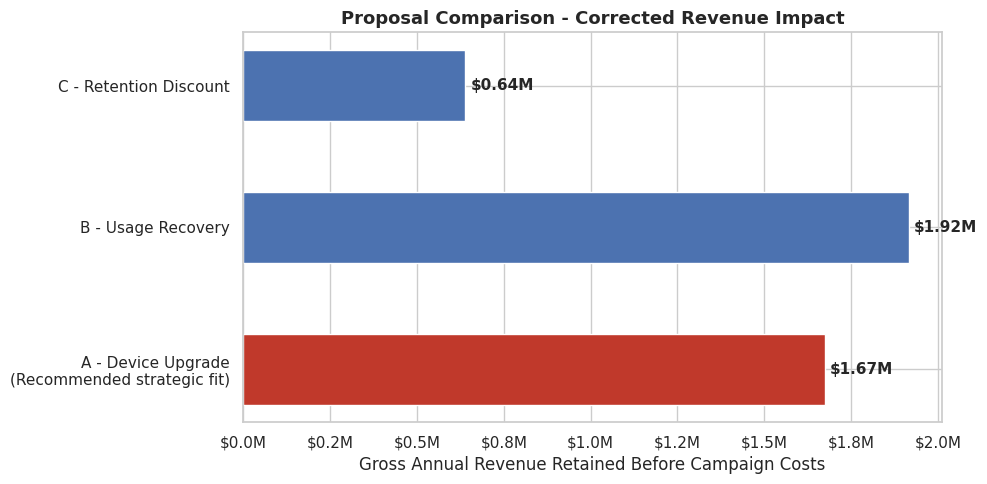

In [18]:
# Revenue comparison visualisation
labels = ['A - Device Upgrade\n(Recommended strategic fit)', 'B - Usage Recovery', 'C - Retention Discount']
revenues = [rev_a, rev_b, rev_c]
bar_colors = ['#C0392B', '#4C72B0', '#4C72B0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, revenues, color=bar_colors, edgecolor='white', height=0.5)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_xlabel('Gross Annual Revenue Retained Before Campaign Costs')
ax.set_title('Proposal Comparison - Corrected Revenue Impact',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, revenues):
    ax.text(bar.get_width()+15000, bar.get_y()+bar.get_height()/2,
            f'${val/1e6:.2f}M', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()



### 5.3 Net Impact Sensitivity: When Does the Device Campaign Pay Off?

The slide deck reports **gross retained revenue**. A device-upgrade campaign also has costs, especially handset subsidy and outreach cost. This sensitivity check shows why the recommendation must be piloted with a control group before full rollout.


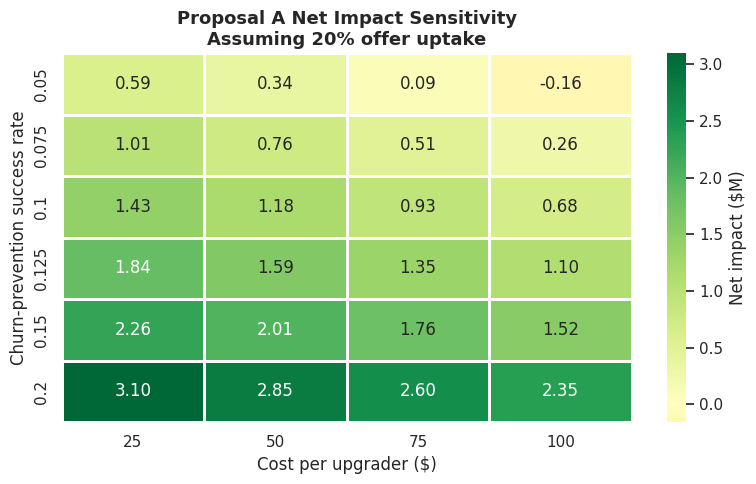

Base-case net impact for Proposal A:
  Success rate       : 10.0% of expected churners prevented
  Uptake rate        : 20.0% of targeted customers accept offer
  Cost per upgrader  : $50
  Gross revenue      : $1,674,067
  Campaign cost      : $497,950
  Net impact         : $1,176,117

Business insight: Proposal A remains attractive under moderate subsidy costs, but the rollout should be gated by measured uplift and net ROI, not gross revenue alone.


In [19]:
# Proposal A net-impact sensitivity
# Assumption: contacted customers are the old-device segment. Uptake = share accepting the device offer.
# Cost per upgrader includes device subsidy + contact/operations cost.
contacted_customers = len(seg_a)
success_rates = np.array([0.05, 0.075, 0.10, 0.125, 0.15, 0.20])
uptake_rates = np.array([0.10, 0.20, 0.30, 0.40])
cost_per_upgrader = np.array([25, 50, 75, 100])

sensitivity_rows = []
for success in success_rates:
    _, retained_customers, gross_revenue = proposal_impact(seg_a, reduction_rate=success)
    for uptake in uptake_rates:
        upgraders = contacted_customers * uptake
        for cost in cost_per_upgrader:
            campaign_cost = upgraders * cost
            net_impact = gross_revenue - campaign_cost
            sensitivity_rows.append({
                'success_rate': success,
                'uptake_rate': uptake,
                'cost_per_upgrader': cost,
                'gross_revenue': gross_revenue,
                'campaign_cost': campaign_cost,
                'net_impact': net_impact,
            })

sensitivity = pd.DataFrame(sensitivity_rows)
base_case = sensitivity[
    (sensitivity['success_rate'] == 0.10) &
    (sensitivity['uptake_rate'] == 0.20) &
    (sensitivity['cost_per_upgrader'] == 50)
].iloc[0]

heatmap_data = sensitivity[
    (sensitivity['uptake_rate'] == 0.20)
].pivot(index='success_rate', columns='cost_per_upgrader', values='net_impact') / 1_000_000

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Net impact ($M)'},
)
plt.title('Proposal A Net Impact Sensitivity\nAssuming 20% offer uptake', fontsize=13, fontweight='bold')
plt.xlabel('Cost per upgrader ($)')
plt.ylabel('Churn-prevention success rate')
plt.tight_layout()
plt.show()

print('Base-case net impact for Proposal A:')
print(f"  Success rate       : {base_case['success_rate']:.1%} of expected churners prevented")
print(f"  Uptake rate        : {base_case['uptake_rate']:.1%} of targeted customers accept offer")
print(f"  Cost per upgrader  : ${base_case['cost_per_upgrader']:.0f}")
print(f"  Gross revenue      : ${base_case['gross_revenue']:,.0f}")
print(f"  Campaign cost      : ${base_case['campaign_cost']:,.0f}")
print(f"  Net impact         : ${base_case['net_impact']:,.0f}")
print()
print('Business insight: Proposal A remains attractive under moderate subsidy costs, but the rollout should be gated by measured uplift and net ROI, not gross revenue alone.')


### 5.3 Recommendation - Proposal A: Device Upgrade Campaign

**Why Proposal A remains the recommendation:**

| Criterion | A - Device Upgrade | B - Usage Recovery | C - Retention Discount |
|---|---|---|---|
| Segment size | ~50,000 customers | ~54,000 customers | ~29,000 customers |
| Segment churn rate | ~55.4% | ~51.2% | ~55.0% |
| Gross annual revenue retained before cost | **~$1.67M** | ~$1.92M | ~$0.64M |
| ML alignment | Strong: `eqpdays` is the clearest model/business signal | Strong secondary signal: usage decline | Weaker and margin-risky |
| Strategic fit | Strong: supports 5G migration and contract renewal | Good for tactical save offers | Risky: discounts can train price shopping |
| Implementation risk | Requires subsidy and pilot ROI control | Easier to test quickly | Margin erosion risk |

Proposal B has the highest gross retained-revenue estimate, so it should be used as a **supporting prioritization layer**. The recommended program is therefore a **device-led retention campaign** aimed at aging-device customers, with outreach prioritized by model churn probability and declining usage.

**Implementation Plan:**
1. **Score all subscribers** using the XGBoost model.
2. **Prioritize old-device customers** (`eqpdays > 342`) who also show high predicted churn risk and/or declining usage.
3. **Offer a subsidized 4G/5G device upgrade** tied to a 12-month renewal. Keep a strict campaign-cost cap because device subsidies can erase the retained-revenue benefit.
4. **Run an A/B test:** hold out a control group, track 90-day churn, uptake, subsidy cost, and retained revenue.
5. **Scale only if net impact is positive:** `net impact = gross retained revenue - device subsidy - campaign/contact cost`.

**Corrected quantified impact:** under a conservative assumption that the campaign prevents **10% of expected churners** in the old-device segment, Proposal A protects about **$1.67M in gross annual revenue before campaign costs**. The A/B test determines whether the net ROI justifies full rollout.

---

## Conclusion

By combining XGBoost churn scoring (ROC-AUC: about 0.679) with a targeted device upgrade campaign, Company A can move from reactive churn reporting to proactive retention management.

The final recommendation is not "give every customer a discount." It is to use the model to focus expensive interventions on customers where the business has an actionable lever: aging devices, rising churn risk, and visible usage decline.



---
## References

1. MEA Tech Watch (2025). *Egypt Reaches 120 Million Mobile Phone Subscriptions in 2024.* https://meatechwatch.com/2025/06/30/egypt-reaches-120-million-mobile-phone-subscriptions-in-2024-ranking-second-in-africa/
2. IMARC Group (2025). *Egypt Telecom Market Size, Share, Growth & Forecast 2034.* https://www.imarcgroup.com/egypt-telecom-market
3. Mordor Intelligence (2026). *Egypt Telecom MNO Market Size, Share & Industry Trends 2031.* https://www.mordorintelligence.com/industry-reports/egypt-telecom-market
4. Reichheld, F. & Schefter, P. (2000). E-Loyalty: Your Secret Weapon on the Web. *Harvard Business Review*, 78(4), 105-113.
5. Verbeke, W. et al. (2012). New insights into churn prediction in the telecommunication sector. *European Journal of Operational Research*, 218(1), 211-229.
6. Scikit-learn documentation: https://scikit-learn.org/stable/
7. XGBoost documentation: https://xgboost.readthedocs.io/
8. Claude AI (Anthropic). Used for notebook review, requirement checking, analytical feedback, and generating draft versions that were subsequently       modified and finalized. Conversation: [https://claude.ai/share/c124d322-7d74-4f18-b0fe-4ec2542ba829]


